In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('CARS.csv')

In [3]:
data.head()

,make,model,year,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption,co2_emissions,extra_field
0,Toyota,Camry,2023,Midsize,2.5,4,Automatic,Petrol,7.8,180,60
1,Toyota,Corolla,2024,Compact,1.8,4,CVT,Petrol,6.5,150,50
2,Toyota,RAV4,2023,SUV,2.5,4,Automatic,Hybrid,5.9,135,55
3,Toyota,Highlander,2023,SUV,3.5,6,Automatic,Petrol,10.2,235,70
4,Toyota,Land Cruiser,2024,SUV,4.0,6,Automatic,Petrol,14.0,320,100


In [4]:
df = pd.DataFrame(data)

df = df[ df['co2_emissions'] < 431 ]
df = df[ df['co2_emissions'] > 110 ]

df = df.drop( ['make', 'year',  'model', 'vehicle_class', 'transmission', 'cylinders', 'transmission', 'fuel_consumption', 'fuel_type', 'extra_field'], axis = 1 )
df = df.reset_index( drop = True )

In [5]:
df.head()

,engine_size,co2_emissions
0,2.5,180
1,1.8,150
2,2.5,135
3,3.5,235
4,4.0,320


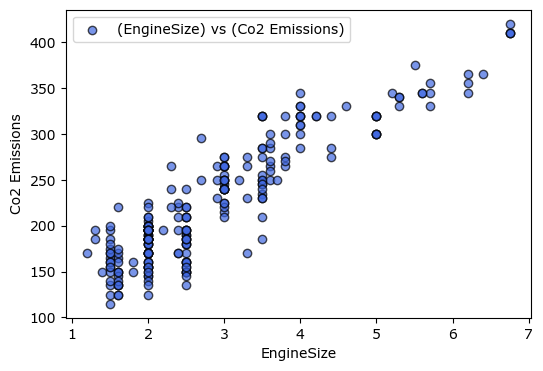

In [6]:
plt.figure( figsize = (6, 4) )

plt.scatter( df[['engine_size']], df[['co2_emissions']], color = 'royalblue', edgecolor = 'k', alpha = 0.7, label = '(EngineSize) vs (Co2 Emissions)' )

plt.xlabel('EngineSize')
plt.ylabel('Co2 Emissions')

plt.legend()

In [7]:
from sklearn.model_selection import train_test_split

x = df[[ 'engine_size' ]]
y = df[[ 'co2_emissions' ]]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 7)

print(f"\nX (Shape): {x_test.shape} {x_train.shape}\n\nY (Shape): {y_test.shape} {y_train.shape}\n")


X (Shape): (75, 1) (172, 1)

Y (Shape): (75, 1) (172, 1)



In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_normalize = scaler.fit_transform(x_train)
x_test_normalize = scaler.transform(x_test)

In [9]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()

regr.fit( x_train_normalize , y_train )

print(f"\nCOEFFICIENT: { regr.coef_[0][0] }\n\nINTERCEPT: { regr.intercept_[0] }\n")


COEFFICIENT: 59.26293915799064

INTERCEPT: 219.65116279069767



In [10]:
pred = regr.predict( x_test_normalize )

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"\n1) r2_score: {r2_score(y_test, pred):1.3f}\n\n2) MAE: {mean_absolute_error(y_test, pred):1.4f}\n\n3) MSE: {mean_squared_error(y_test, pred):1.4f}\n")


1) r2_score: 0.847

2) MAE: 20.9006

3) MSE: 690.6548



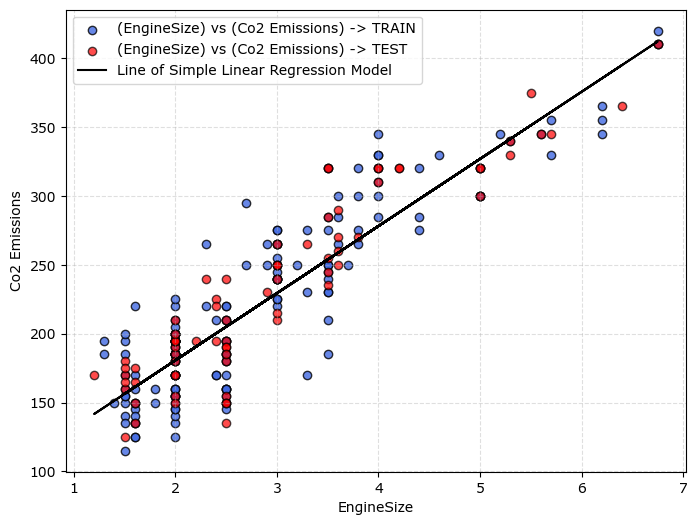

In [13]:
plt.figure( figsize = (8, 6) )

plt.scatter( x_train, y_train, color = 'royalblue', label = '(EngineSize) vs (Co2 Emissions) -> TRAIN', alpha = 0.8, edgecolor = 'k' )
plt.scatter( x_test, y_test, color = 'r',label = '(EngineSize) vs (Co2 Emissions) -> TEST', alpha = 0.7, edgecolor = 'k' )

plt.plot( x_test, pred, 'k', label = 'Line of Simple Linear Regression Model' )

plt.xlabel('EngineSize')
plt.ylabel('Co2 Emissions')

plt.grid( True, linestyle = '--', alpha = 0.4 )

plt.legend()